# 4. Operators as matrices, and the ladder

Notebook 3 solved the oscillator with calculus: guess a function, differentiate,
check the eigenvalue. Here we solve it again and never write down a wavefunction.

The starting observation is the one that ended notebook 3. The levels are
**equally spaced**, every gap exactly $\hbar\omega$. If the states sit on a ladder
with uniform rungs, there ought to be operators that move you one rung up and one
rung down, and the whole spectrum should follow from how those two operators
relate to each other. They do, and it does.

This also changes the *representation*. A state stops being a function of $x$ and
becomes a column of numbers -- its amplitudes in the energy basis. Operators
become matrices. That is the picture quantum computing lives in, so this notebook
is the hinge of the series.

## 4.1 Some linear algebra helpers

`scmutils` has matrices, complex numbers, and `*` overloaded for matrix products.
Four things it does not hand us directly: an identity, a conjugate transpose, a
commutator, and a column vector.

In [1]:
(define (eye n) (m:generate n n (lambda (i j) (if (= i j) 1 0))))

;; Conjugate transpose, written A-dagger. Note m:elementwise is curried.
(define (dagger M) (m:transpose ((m:elementwise conjugate) M)))

(define (commutator A B) (- (* A B) (* B A)))

(define (ket lst) (m:generate (length lst) 1 (lambda (i j) (list-ref lst i))))

eye 
dagger 
commutator 
ket 

## 4.2 The ladder operators

Define $\hat a$ (*lowering*, or annihilation) and $\hat a^\dagger$ (*raising*, or
creation) by what they do to the energy eigenstates:

$$\hat a\,|n\rangle = \sqrt{n}\,|n-1\rangle, \qquad
  \hat a^\dagger|n\rangle = \sqrt{n+1}\,|n+1\rangle .$$

In the basis $|0\rangle, |1\rangle, |2\rangle, \dots$, $\hat a$ is the matrix with
$\sqrt{n}$ on the superdiagonal. The basis is infinite, so to get a matrix at all
we **truncate** at some number of levels and keep an eye on what that costs.

In [2]:
(define (lowering D)
  (m:generate D D (lambda (i j) (if (= j (+ i 1)) (sqrt (+ i 1)) 0))))

(define DIM 6)
(define a  (lowering DIM))
(define a+ (dagger a))
(print-expression a)

lowering 
DIM 
a 
a+ 
(matrix-by-rows (list 0 1 0 0 0 0)
                (list 0 0 1.4142135623730951 0 0 0)
                (list 0 0 0 1.7320508075688772 0 0)
                (list 0 0 0 0 2 0)
                (list 0 0 0 0 0 2.23606797749979)
                (list 0 0 0 0 0 0))

;No return value.

## 4.3 The number operator

The product $\hat N = \hat a^\dagger \hat a$ lowers and then raises, so on
$|n\rangle$ it gives $\sqrt{n}\cdot\sqrt{n}\,|n\rangle = n|n\rangle$. It should be
diagonal, counting the rungs.

In [3]:
(print-expression (* a+ a))

(matrix-by-rows (list 0 0 0 0 0 0)
                (list 0 1 0 0 0 0)
                (list 0 0 2.0000000000000004 0 0 0)
                (list 0 0 0 2.9999999999999996 0 0)
                (list 0 0 0 0 4 0)
                (list 0 0 0 0 0 5.000000000000001))

;No return value.

$\mathrm{diag}(0, 1, 2, 3, 4, 5)$. The eigenvalues of $\hat N$ *are* the level
labels, which is why $n$ is called the **occupation number**: in the field-theory
reading of this system, $|n\rangle$ is the state with $n$ quanta in it, $\hat a$
destroys one and $\hat a^\dagger$ creates one.

The single relation that generates everything is the commutator
$[\hat a, \hat a^\dagger] = 1$.

In [4]:
(print-expression (commutator a a+))

(matrix-by-rows (list 1 0 0 0 0 0)
                (list 0 1.0000000000000004 0 0 0 0)
                (list 0 0 .9999999999999991 0 0 0)
                (list 0 0 0 1.0000000000000004 0 0)
                (list 0 0 0 0 1.0000000000000009 0)
                (list 0 0 0 0 0 -5.000000000000001))

;No return value.

The identity, as promised -- **except in the bottom right corner**, which reads
$-5$ instead of $1$.

That is the truncation, and it is worth understanding rather than hiding. Our
matrix $\hat a^\dagger$ cannot raise $|5\rangle$ to $|6\rangle$, because we never
gave the matrix a sixth row, so it maps $|5\rangle$ to zero instead. The commutator
loses the $6$ it should have gained and keeps the $-5$ from the other term. **The
top rung is always wrong, and everything below it is exact.** Work in a space
several levels bigger than the physics you care about and the error never reaches
you.

## 4.4 Position, momentum, and the canonical commutator

Inverting the definitions of $\hat a$ and $\hat a^\dagger$ (still in natural
units, $\hbar = m = \omega = 1$):

$$\hat x = \frac{\hat a + \hat a^\dagger}{\sqrt 2}, \qquad
  \hat p = i\,\frac{\hat a^\dagger - \hat a}{\sqrt 2}.$$

In [5]:
(define xop (* (/ 1 (sqrt 2)) (+ a a+)))
(define pop (* (/ +i (sqrt 2)) (- a+ a)))
(print-expression (commutator xop pop))

xop 
pop 
(matrix-by-rows (list +.9999999999999998i 0 +0.i 0 0 0)
                (list 0 +1.0000000000000002i 0 +0.i 0 0)
                (list +0.i 0 +.9999999999999996i 0 +0.i 0)
                (list 0 +0.i 0 +.9999999999999996i 0 +0.i)
                (list 0 0 +0.i 0 +1.i 0)
                (list 0 0 0 +0.i 0 -4.999999999999999i))

;No return value.

$[\hat x, \hat p] = i$ -- that is $i\hbar$ with $\hbar = 1$ -- on every rung but
the top one. This is *the* commutation relation of quantum mechanics. In notebook
2 it was hidden inside $\hat p = -i\hbar\,d/dx$: the operator identity
$x\frac{d}{dx} - \frac{d}{dx}x = -1$ is the same statement in the language of
functions. Heisenberg's uncertainty relation is a theorem about it, which is why
notebook 3 found $\Delta x \Delta p = \tfrac12$ and not $0$.

## 4.5 The spectrum, for the third time

$\hat H = \tfrac12(\hat p^2 + \hat x^2)$. Substituting the ladder operators and
using $[\hat a, \hat a^\dagger] = 1$ gives
$\hat H = \hat a^\dagger \hat a + \tfrac12 = \hat N + \tfrac12$. Let the matrices
confirm it.

In [6]:
(define hop (* 1/2 (+ (* pop pop) (* xop xop))))
(print-expression hop)

hop 
(matrix-by-rows (list .4999999999999999 0 0. 0 0 0)
                (list 0 1.5 0 0. 0 0)
                (list 0. 0 2.5 0 0. 0)
                (list 0 0. 0 3.499999999999999 0 0.)
                (list 0 0 0. 0 4.499999999999999 0)
                (list 0 0 0 0. 0 2.4999999999999996))

;No return value.

Diagonal, reading $\tfrac12, \tfrac32, \tfrac52, \tfrac72, \tfrac92$ -- and then a
wrong entry in the corner, from the same truncation. Compare notebook 3, which got
those same numbers out of Hermite polynomials and symbolic differentiation. Same
spectrum, no calculus.

With more room, the good part of the spectrum simply gets longer. Below, the
diagonal of $\hat H$ in a 12-level truncation: correct through $n = 10$, wrong on
the last rung only.

In [7]:
(define (h-diagonal D)
  (let* ((al (lowering D))
         (ar (dagger al))
         (x (* (/ 1 (sqrt 2)) (+ al ar)))
         (p (* (/ +i (sqrt 2)) (- ar al)))
         (h (* 1/2 (+ (* p p) (* x x)))))
    (map (lambda (n) (real-part (ref h n n))) (iota D))))

(h-diagonal 12)

h-diagonal 
#|
(.4999999999999999 1.5
                   2.5
                   3.499999999999999
                   4.499999999999999
                   5.499999999999998
                   6.499999999999998
                   7.5
                   8.5
                   9.5
                   10.5
                   5.499999999999998)
|#

## 4.6 Time evolution

A state evolves by $|\psi(t)\rangle = e^{-i\hat H t/\hbar}|\psi(0)\rangle$. In the
energy basis $\hat H$ is diagonal, so the exponential is diagonal too: the
amplitude of $|n\rangle$ just picks up the phase $e^{-i(n+1/2)t}$. No matrix
exponential is needed.

In [8]:
(define (evolve state t)
  (m:generate (m:num-rows state) 1
    (lambda (n j) (* (exp (* -1 +i (+ n 1/2) t)) (ref state n 0)))))

;; <A> = <psi| A |psi>, real for a Hermitian A.
(define (expectation A state) (real-part (ref (* (dagger state) A state) 0 0)))

evolve 
expectation 

Two states to compare. A single eigenstate $|0\rangle$, and the superposition
$(|0\rangle + |1\rangle)/\sqrt2$.

In [9]:
(define ground (ket (list 1 0 0 0 0 0)))
(define mixed  (ket (list (/ 1 (sqrt 2)) (/ 1 (sqrt 2)) 0 0 0 0)))

(map (lambda (t) (list t
                       'ground (expectation xop (evolve ground t))
                       'mixed  (expectation xop (evolve mixed t))))
     (list 0. 1. 2.))

ground 
mixed 
#|
((0. ground 0 mixed .7071067811865474) (1. ground 0 mixed .38205142437008965)
                                       (2. ground 0 mixed -.2942602500918141))
|#

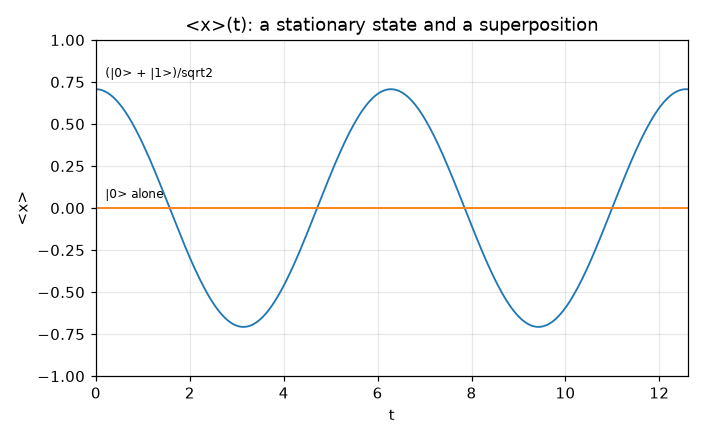

In [10]:
%%plot --title "<x>(t): a stationary state and a superposition" --xlabel "t" --ylabel "<x>" --grid
(define win (frame 0. 12.6 -1. 1.))
(plot-function win (lambda (t) (expectation xop (evolve mixed t))) 0. 12.6 .05)
(plot-function win (lambda (t) (expectation xop (evolve ground t))) 0. 12.6 .05)
(graphics-draw-text win .2 .78 "(|0> + |1>)/sqrt2")
(graphics-draw-text win .2 .06 "|0> alone")

The eigenstate is flat. That is what **stationary state** means: every observable
is frozen, because the state only picks up an overall phase $e^{-iE_0t/\hbar}$ and
an overall phase cancels in $\langle\psi|A|\psi\rangle$. Nothing oscillates in an
energy eigenstate, not even the ground state of an oscillator.

The superposition oscillates at exactly $\omega$, amplitude $1/\sqrt2$. The motion
comes from the *relative* phase between $|0\rangle$ and $|1\rangle$, which turns at
the rate $(E_1 - E_0)/\hbar = \omega$. **Interference between energy levels is what
makes anything happen in quantum mechanics.**

## 4.7 The most classical state there is

Can a quantum oscillator swing like a real one? Yes: a **coherent state** is the
eigenstate of the lowering operator, $\hat a|\alpha\rangle = \alpha|\alpha\rangle$,
which in the number basis is

$$|\alpha\rangle = e^{-|\alpha|^2/2}\sum_n \frac{\alpha^n}{\sqrt{n!}}\,|n\rangle .$$

In [11]:
(define BIG 24)
(define aB  (lowering BIG))
(define xB  (* (/ 1 (sqrt 2)) (+ aB (dagger aB))))
(define (factorial n) (if (= n 0) 1 (* n (factorial (- n 1)))))

(define (coherent D alpha)
  (m:generate D 1 (lambda (n j)
    (* (exp (* -1/2 (square alpha))) (/ (expt alpha n) (sqrt (factorial n)))))))

(define cs (coherent BIG 2.))          ; alpha = 2

(define (spread A state)
  (- (expectation (* A A) state) (square (expectation A state))))

(map (lambda (t) (list t
                       'mean-x (expectation xB (evolve cs t))
                       'var-x  (spread xB (evolve cs t))))
     (list 0. 1. 2. 3.14159265))

BIG 
aB 
xB 
factorial 
coherent 
cs 
spread 
#|
((0. mean-x 2.828427124577239 var-x .4999999987280104)
 (1. mean-x 1.5282056973890743 var-x .5000000000134843)
 (2. mean-x -1.1770410002969485 var-x .5000000002290659)
 (3.14159265 mean-x -2.828427124577239 var-x .4999999987280086))
|#

$\langle x\rangle(t) = 2\sqrt2 \cos t$ -- the classical trajectory of notebook 1,
exactly -- and the variance sits at $1/2$ and *does not move*. A coherent state is
the ground-state Gaussian picked up and slid along the classical orbit without
spreading. It is the bridge back: a laser beam is in such a state, and so is any
oscillator driven hard enough that quantum granularity stops showing.

Note $\langle x \rangle$ at $t = \pi$ is $-2\sqrt2$, the other turning point, and
the variance is unchanged there too.

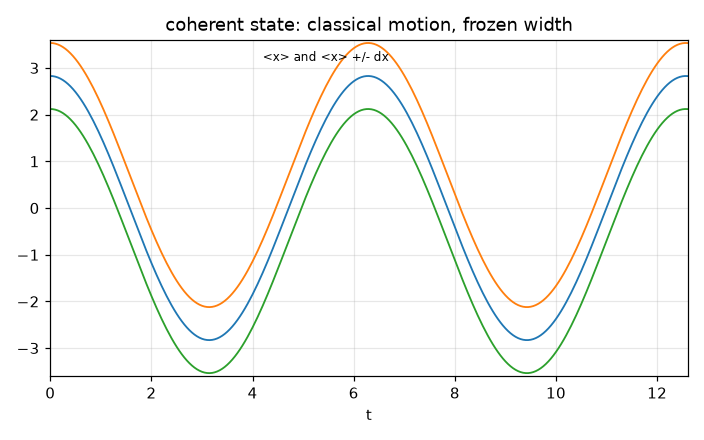

In [12]:
%%plot --title "coherent state: classical motion, frozen width" --xlabel "t" --grid
(define win (frame 0. 12.6 -3.6 3.6))
(plot-function win (lambda (t) (expectation xB (evolve cs t))) 0. 12.6 .05)
(plot-function win (lambda (t) (+ (expectation xB (evolve cs t))
                                  (sqrt (spread xB (evolve cs t))))) 0. 12.6 .05)
(plot-function win (lambda (t) (- (expectation xB (evolve cs t))
                                  (sqrt (spread xB (evolve cs t))))) 0. 12.6 .05)
(graphics-draw-text win 4.2 3.15 "<x> and <x> +/- dx")

Three curves: the mean, and the mean plus and minus one standard deviation. The
band between them has constant width -- the packet slides without dispersing,
which is special to the harmonic potential. In any other well the packet spreads.

## What to carry forward

- The same physics has two representations: functions of $x$, or **columns of
  amplitudes** with operators as matrices.
- The ladder relation $[\hat a, \hat a^\dagger] = 1$ generates the whole spectrum.
- Truncating an infinite basis is exact except at the top rung. Leave headroom.
- Time evolution is $e^{-i\hat Ht/\hbar}$; in the energy basis it is just phases.
- An eigenstate is frozen; superpositions move.

Next: [one qubit](05-one-qubit.ipynb). Take this matrix picture, throw away all
but two levels, and you have the object quantum computers are built from.